# Temps par itération en ABC-SMC vs permABC-SMC

## Setup (important)

Ce projet utilise **JAX**. Si tu vois une erreur du type *« jaxlib was built using AVX instructions »* ou *« x86 Python on ARM »*, c’est que le **kernel Jupyter** pointe vers un Python incompatible (souvent **Anaconda x86** sur Mac Apple Silicon).

**À faire :** dans Cursor / Jupyter, choisis le kernel associé à ton environnement **`permabc`** (`pyenv`) ou tout Python **ARM natif** où JAX est installé, puis redémarre le kernel et réexécute les cellules depuis le haut.

---

Ce notebook investigue pourquoi le **temps wall-clock par itération** ne semble pas évoluer de façon linéaire (et peut **accélérer** nettement en cours de route), surtout pour **permABC-SMC**.

## Mécanisme principal (permABC) : *smart acceptance*

Dans `permabc/core/distances.py`, la fonction `optimal_index_distance` calcule d'abord la distance avec l'**assignation courante** $(y\_\text{index}, z\_\text{index})$ sans reconstruire toutes les matrices coûteuses pour tout le monde. Ensuite :

- seules les particules avec **distance courante $\ge \varepsilon$** déclenchent un **LSA** (Hungarian) sur la sous-population ;
- si **toutes** les distances courantes sont $< \varepsilon$, alors **0 LSA** est résolu sur ce passage.

Quand la chaîne se concentre près du posterior et que les propositions MH sont petites, les propositions restent souvent compatibles avec la permutation déjà en place → **beaucoup moins de LSA** par itération → itérations plus rapides.

## Autres facteurs (ABC-SMC et permABC-SMC)

- **Seuil $\varepsilon$** : quand il se stabilise (`epsilon == epsilon_target`), le comportement des acceptations change.
- **Resampling** : coût ponctuel quand l'ESS est bas.
- **Taux d'acceptation MH** : influence la qualité du mélange (diagnostic).

Les graphiques ci-dessous comparent `Time`, `N_sim`, `N_lsa` (perm), `Eps_values` et le taux d'acceptation le long des itérations.

**Note d'indexation** : le premier élément des listes (`Time[0]`, `N_lsa[0]`, …) correspond à l'**initialisation** (avant la boucle SMC `t=1,2,…`).

In [1]:
import sys
from pathlib import Path

print("Python utilisé:", sys.executable)

# Racine du projet (répertoire qui contient le package permabc/)
ROOT = Path.cwd()
for _ in range(4):
    if (ROOT / "permabc").is_dir():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

try:
    import jax
    from jax import random
except RuntimeError as e:
    msg = str(e).lower()
    if "avx" in msg or "arm" in msg or "operating system" in msg:
        raise RuntimeError(
            "JAX/jaxlib incompatible avec ce Python (ex. conda x86 sur Apple Silicon).\n"
            "→ Sélectionne le kernel Jupyter lié à pyenv `permabc` (ou un Python ARM avec JAX), "
            "puis Kernel → Restart et réexécute.\n"
            f"Détail: {e}"
        ) from e
    raise

from permabc.algorithms.smc import abc_smc, perm_abc_smc
from permabc.core.kernels import KernelTruncatedRW
from permabc.models.Gaussian_with_no_summary_stats import GaussianWithNoSummaryStats

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

Python utilisé: /Users/antoineluciano/.pyenv/versions/3.10.13/envs/permabc/bin/python


In [2]:
# --- Paramètres d'expérience ---
# Astuce : pour un test rapide, baisse `n_particles`, `N_points` et/ou `N_iteration_max`.
import jax.numpy as jnp
SEED = 0
K = 10
n_obs = 10
n_particles = 1000
N_points = jnp.inf          # budget simulations (× K) — voir N_sim_max ci-dessous
stopping_rate = 0.02
N_iteration_max = jnp.inf     # plafond d'itérations SMC (évite des runs interminables)

key = random.PRNGKey(SEED)
model = GaussianWithNoSummaryStats(K=K, n_obs=n_obs)

key, k_prior, k_data = random.split(key, 3)
true_thetas = model.prior_generator(k_prior, n_particles=1)
y_obs = model.data_generator(k_data, true_thetas)

kernel = KernelTruncatedRW

print("Running ABC-SMC...")
key, k1 = random.split(key)
model.reset_weights_distance()
res_abc = abc_smc(
    key=k1,
    model=model,
    n_particles=n_particles,
    epsilon_target=0.0,
    y_obs=y_obs,
    kernel=kernel,
    verbose=1,
    Final_iteration=0,
    update_weights_distance=False,
    stopping_accept_rate=stopping_rate,
    N_sim_max=N_points * K,
    N_iteration_max=N_iteration_max,
)

print("Running permABC-SMC...")
key, k2 = random.split(key)
model.reset_weights_distance()
res_perm = perm_abc_smc(
    key=k2,
    model=model,
    n_particles=n_particles,
    epsilon_target=0.0,
    y_obs=y_obs,
    kernel=kernel,
    verbose=1,
    Final_iteration=0,
    update_weights_distance=False,
    stopping_accept_rate=stopping_rate,
    N_sim_max=N_points * K,
    N_iteration_max=N_iteration_max,
    parallel=True,
)

print("Done. ABC:", len(res_abc["Time"]), "records; perm:", len(res_perm["Time"]), "records")

Running ABC-SMC...
Iteration 0: Epsilon = inf, ESS = 1000, Acc. rate = 100%, Unique particles = 1000

Iteration 1: Epsilon = 10.2145, ESS = 950, Acc. rate = 1.58%
Uniqueness rates: Particles = 100.0%, Parameters = 100.0%, Local = 100.0%, Global = 100.0%
Overall acceptance rate too low (1.58% < 2.00%), stopping at epsilon = 10.214474218001152
Global acceptance rate too low (1.58% < 2.00%), stopping at epsilon = 10.214474218001152
Local acceptance rate too low (1.58% < 2.00%), stopping at epsilon = 10.214474218001152

Resampling... 950 unique particles left
Iteration 2: Epsilon = 10.2145, ESS = 1000, Acc. rate = 2.10%
Uniqueness rates: Particles = 95.4%, Parameters = 95.4%, Local = 95.4%, Global = 95.4%

Running permABC-SMC...
Iteration 0: Epsilon = inf, ESS = 1000, Acc. rate = 100%, Unique particles = 1000

Iteration 1: Epsilon = 6.4695, ESS = 950, Acc. rate = 18.84%
Uniqueness rates: Particles = 100.0%, Parameters = 100.0%, Local = 100.0%, Global = 100.0%

Iteration 2: Epsilon = 6.1863

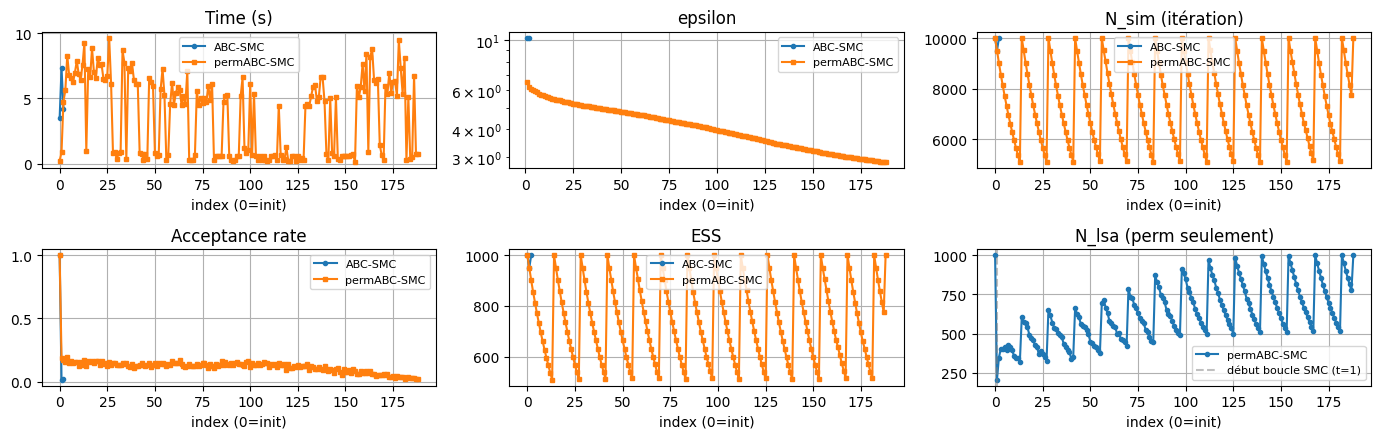

In [6]:
def _extract(name, res):
    t = np.asarray(res["Time"], dtype=float)
    eps = np.asarray(res["Eps_values"], dtype=float)
    nsim = np.asarray(res["N_sim"], dtype=float)
    acc = np.asarray(res["Acc_rate"], dtype=float)
    ess = np.asarray(res["Ess"], dtype=float)
    nlsa = None
    if "N_lsa" in res:
        nlsa = np.asarray(res["N_lsa"], dtype=float)
    return {
        "name": name,
        "Time": t,
        "Eps": eps,
        "Nsim": nsim,
        "Acc": acc,
        "Ess": ess,
        "N_lsa": nlsa,
    }


def plot_comparison(d_abc, d_perm):
    fig, axes = plt.subplots(2, 3, figsize=(14, 4.5))

    # Index 0 = init ; itérations SMC = 1..T-1
    for ax, title, key, d0, d1, logy in [
        (axes[0, 0], "Time (s)", "Time", d_abc, d_perm, False),
        (axes[0, 1], "epsilon", "Eps", d_abc, d_perm, True),
        (axes[0, 2], "N_sim (itération)", "Nsim", d_abc, d_perm, False),
        (axes[1, 0], "Acceptance rate", "Acc", d_abc, d_perm, False),
        (axes[1, 1], "ESS", "Ess", d_abc, d_perm, False),
        (axes[1, 2], "N_lsa (perm seulement)", "N_lsa", None, d_perm, False),
    ]:
        if key == "N_lsa":
            if d1["N_lsa"] is None:
                ax.set_visible(False)
                continue
            x = np.arange(len(d1["N_lsa"]))
            ax.plot(x, d1["N_lsa"], "o-", ms=3, label="permABC-SMC")
            ax.axvline(1, color="gray", ls="--", alpha=0.5, label="début boucle SMC (t=1)")
            ax.set_title(title)
            ax.set_xlabel("index (0=init)")
            ax.legend(fontsize=8)
            continue
        x0 = np.arange(len(d0[key]))
        x1 = np.arange(len(d1[key]))
        ax.plot(x0, d0[key], "o-", ms=3, label="ABC-SMC")
        ax.plot(x1, d1[key], "s-", ms=3, label="permABC-SMC")
        ax.set_title(title)
        ax.set_xlabel("index (0=init)")
        if logy:
            ax.set_yscale("log")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


d_abc = _extract("abc", res_abc)
d_perm = _extract("perm", res_perm)
plot_comparison(d_abc, d_perm)

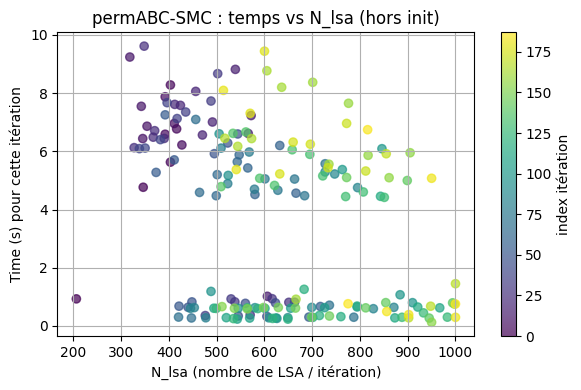

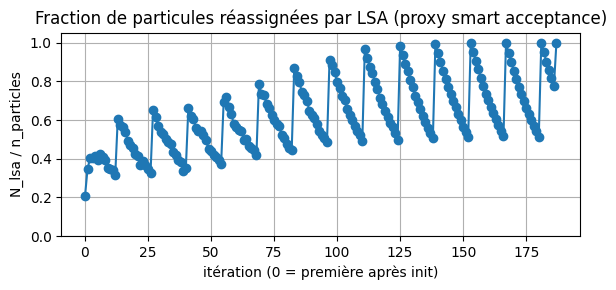

In [7]:
# Corrélation empirique : temps d'itération vs charge LSA (perm)
# On enlève l'index 0 (init) pour ne garder que les itérations SMC.

nl = d_perm["N_lsa"]
tt = d_perm["Time"]
if nl is not None and len(nl) > 2:
    mask = slice(1, None)
    t_it = tt[mask]
    n_it = nl[mask]
    fig, ax = plt.subplots(figsize=(6, 4))
    sc = ax.scatter(n_it, t_it, alpha=0.7, c=np.arange(len(n_it)), cmap="viridis")
    ax.set_xlabel("N_lsa (nombre de LSA / itération)")
    ax.set_ylabel("Time (s) pour cette itération")
    ax.set_title("permABC-SMC : temps vs N_lsa (hors init)")
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("index itération")
    plt.tight_layout()
    plt.show()

    # Ratio : fraction de particules pour lesquelles un LSA est nécessaire
    frac = n_it / n_particles
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(np.arange(len(frac)), frac, "o-")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("itération (0 = première après init)")
    ax.set_ylabel("N_lsa / n_particles")
    ax.set_title("Fraction de particules réassignées par LSA (proxy smart acceptance)")
    plt.tight_layout()
    plt.show()
else:
    print("N_lsa non disponible ou pas assez d'itérations.")

In [9]:
# ABC-SMC : N_sim est constant par itération (move_smc), donc le temps devrait être
# plus stable que permABC si le coût du simulateur domine. Variations résiduelles :
# resampling, JIT, charge CPU, etc.

ns = d_abc["Nsim"]
if len(ns) > 1:
    print("N_sim unique (hors init):", np.unique(ns[1:]))

N_sim unique (hors init): [ 9500. 10000.]


### Option : désactiver temporairement la smart acceptance

Pour vérifier que **la smart acceptance** est bien la cause principale des accélérations sur permABC, il faudrait comparer deux exécutions (même seed, mêmes paramètres) avec une fonction `optimal_index_distance` qui **ignore** le raccourci (toujours LSA complet).  
Cela n'est pas exposé comme un flag dans le package actuel ; une modification minimale serait d'ajouter un `force_full_lsa=False` dans `optimal_index_distance` ou de bricoler un patch local dans le notebook.

En attendant, le graphe **temps vs N_lsa** ci-dessus sert de preuve empirique : quand `N_lsa` chute, le temps d'itération baisse en général.